In [ ]:
!pip install pandas numpy nltk tensorflow scikit-learn

Loading dataset...
Dataset size: 50000

Sentiment distribution:
sentiment
0    25153
1    24847
Name: count, dtype: int64

Cleaning text...
Cleaning completed

Training: 39801
Testing: 9951


Training: RNN

Epoch 1/15
622/622 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.5002 - loss: 0.6959 - val_accuracy: 0.5029 - val_loss: 0.6931
Epoch 2/15
622/622 ━━━━━━━━━━━━━━━━━━━━ 53s 86ms/step - accuracy: 0.5004 - loss: 0.6932 - val_accuracy: 0.5029 - val_loss: 0.6931
Epoch 3/15
622/622 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.5022 - loss: 0.6932 - val_accuracy: 0.5029 - val_loss: 0.6931
Epoch 4/15
622/622 ━━━━━━━━━━━━━━━━━━━━ 50s 81ms/step - accuracy: 0.5028 - loss: 0.6932 - val_accuracy: 0.5029 - val_loss: 0.6931
Epoch 5/15
622/622 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.5028 - loss: 0.6932 - val_accuracy: 0.5029 - val_loss: 0.6931


Training: LSTM
Epoch 1/15
622/622 ━━━━━━━━━━━━━━━━━━━━ 197s 301ms/step - accuracy: 0.4954 - loss: 0.6939 - val_accuracy: 0.4971 - val_loss: 0

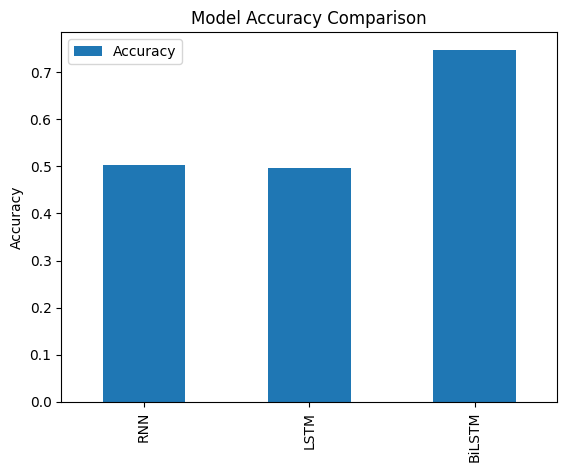

In [1]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

# ===================================
# Download NLTK resources
# ===================================

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# ===================================
# Load Sentiment140 dataset
# ===================================

print("Loading dataset...")

columns = [
    'target',
    'id',
    'date',
    'flag',
    'user',
    'text'
]

df = pd.read_csv(
    'sentiment140.csv',
    encoding='latin-1',
    names=columns,
    engine='python',
    on_bad_lines='skip'
)

df = df[['text', 'target']]

# Convert labels
# 0 = Negative
# 4 = Positive

df['sentiment'] = df['target'].map({
    0: 0,
    4: 1
})

df.dropna(inplace=True)

# Remove duplicate tweets
df.drop_duplicates(
    subset=['text'],
    inplace=True
)

# Shuffle
df = df.sample(
    frac=1,
    random_state=42
)

# Use 50k rows for laptop-friendly training
df = df.sample(
    n=50000,
    random_state=42
)

print("Dataset size:", len(df))

print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

# ===================================
# Text preprocessing
# ===================================

stop_words = set(
    stopwords.words('english')
)

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(
        r"http\S+",
        "",
        text
    )

    # Remove usernames
    text = re.sub(
        r"@\w+",
        "",
        text
    )

    # Remove non-letters
    text = re.sub(
        r"[^a-zA-Z\s]",
        "",
        text
    )

    tokens = word_tokenize(text)

    cleaned_tokens = [

        lemmatizer.lemmatize(word)

        for word in tokens

        if word not in stop_words

    ]

    return " ".join(
        cleaned_tokens
    )

print("\nCleaning text...")

df['cleaned_text'] = df[
    'text'
].apply(
    preprocess_text
)

df = df[
    df['cleaned_text'].str.strip() != ""
]

print("Cleaning completed")

# ===================================
# Text vectorization
# ===================================

MAX_WORDS = 15000
MAX_LEN = 80

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    df['cleaned_text']
)

sequences = tokenizer.texts_to_sequences(
    df['cleaned_text']
)

X = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding='post'
)

y = df['sentiment'].values

# ===================================
# Split data
# ===================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining:", len(X_train))
print("Testing:", len(X_test))

# ===================================
# Model builder
# ===================================

def build_model(model_type):

    model = Sequential()

    model.add(
        Embedding(
            input_dim=MAX_WORDS,
            output_dim=128
        )
    )

    if model_type == "RNN":

        model.add(
            SimpleRNN(
                128,
                dropout=0.3
            )
        )

    elif model_type == "LSTM":

        model.add(
            LSTM(
                128,
                dropout=0.3,
                recurrent_dropout=0.2
            )
        )

    elif model_type == "BiLSTM":

        model.add(
            Bidirectional(
                LSTM(
                    128,
                    dropout=0.3,
                    recurrent_dropout=0.2
                )
            )
        )

    model.add(
        Dense(
            64,
            activation='relu'
        )
    )

    model.add(
        Dropout(0.5)
    )

    model.add(
        Dense(
            1,
            activation='sigmoid'
        )
    )

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


# ===================================
# Callbacks
# ===================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# ===================================
# Train and compare
# ===================================

results = {}

model_types = [
    "RNN",
    "LSTM",
    "BiLSTM"
]

for model_name in model_types:

    print("\n")
    print("="*40)
    print("Training:", model_name)
    print("="*40)

    tf.keras.backend.clear_session()

    model = build_model(
        model_name
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=15,
        batch_size=64,
        validation_data=(
            X_test,
            y_test
        ),
        callbacks=[early_stop],
        verbose=1
    )

    predictions = (
        model.predict(
            X_test,
            verbose=0
        ) > 0.5
    ).astype("int32")

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    report = classification_report(
        y_test,
        predictions,
        output_dict=True,
        zero_division=0
    )

    results[model_name] = {

        "Accuracy":
        round(accuracy,4),

        "Precision":
        round(
            report['macro avg']['precision'],
            4
        ),

        "Recall":
        round(
            report['macro avg']['recall'],
            4
        ),

        "F1-Score":
        round(
            report['macro avg']['f1-score'],
            4
        )
    }

# ===================================
# Final comparison
# ===================================

results_df = pd.DataFrame(
    results
).T

print("\n")
print("="*50)
print("FINAL MODEL COMPARISON")
print("="*50)

print(results_df)

# ===================================
# Accuracy graph
# ===================================

results_df[['Accuracy']].plot(
    kind='bar'
)

plt.title(
    "Model Accuracy Comparison"
)

plt.ylabel(
    "Accuracy"
)

plt.show()

In [2]:
!pip install streamlit

   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.2 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.2 MB 2.7 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.2 MB 2.6 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.2 MB 2.2 MB/s eta 0:00:04
   --------- ------------------------------ 2.1/9.2 MB 2.2 MB/s eta 0:00:04
   ------------- -------------------------- 3.1/9.2 MB 2.5 MB/s eta 0:00:03
   ----------------- ---------------------- 3.9/9.2 MB 2.7 MB/s eta 0:00:02
   ------------------ --------------------- 4.2/9.2 MB 2.6 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.2 MB 2.4 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.2 MB 2.4 MB/s eta 0:00:02
   --------------------- ------------------ 5.0/9.2 MB 2.2 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.2 MB 2.1 MB/s eta 0:00:02
   -----------------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# ===================================
# Save best model + tokenizer
# ===================================

import pickle

# Find best model
best_model_name = results_df['Accuracy'].idxmax()

print("\nBest Model:", best_model_name)

# Save the last trained model
# (BiLSTM is expected to be last in your loop)

model.save("sentiment_model.keras")

# Save tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("\nFiles saved successfully")
print("sentiment_model.keras")
print("tokenizer.pkl")


Best Model: BiLSTM

Files saved successfully
sentiment_model.keras
tokenizer.pkl
